In [89]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
import process_data as dp
import mp_selection 
from morld.pi_morld import PIMORLD
from pymoo.indicators.hv import HV

import mdp_utils
import pymc as pm
import arviz as az
import pickle
from morld.mo_pi import MOPolicyIteration
import bayesian_analysis as ba
import arviz as az


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
state_features = ['TIR', 'TIME_Q', 'GOOD']
feature_names = ['Tiredness', 'Time available', 'Usefulness Belief']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Fun", "Perceived Usefulness", "Diversity", "Expert Usefulness", "Return Willingness"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "difficulty", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Difficulty", "Return Willingness", "Expert Usefulness", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

### Data preparation

First we load the data and process the samples

In [91]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)

df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head(50)

Number of samples after processing: 3111


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,c_idx,s_idx,sp_idx,r_time,r_difficulty,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,...,0,8,1,0.000000,0.000000,0.000000,0.000000,0.666667,0.00,5
1,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,...,0,1,7,0.983333,0.545455,0.909091,1.000000,0.833333,0.66,2
2,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,...,0,7,4,0.993333,0.454545,0.818182,0.714286,0.833333,1.00,1
3,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,...,0,4,8,0.000000,0.000000,0.000000,0.000000,0.833333,0.00,5
4,1111591584,5,5,5,6,4,6,3.0,4.0,6.0,...,0,8,2,0.990000,0.363636,0.909091,1.000000,0.833333,0.66,1
5,1111591584,16,4,4,6,3,6,3.0,3.0,6.0,...,0,2,2,0.993333,0.545455,0.818182,0.857143,0.833333,0.66,1
6,1139851159,1,4,5,5,4,4,2.0,7.0,6.0,...,0,1,5,0.966667,0.818182,0.909091,1.142857,0.666667,0.33,1
7,1178274181,1,2,7,5,6,7,3.0,2.0,6.0,...,0,4,2,0.996667,0.909091,0.636364,0.285714,1.000000,0.66,1
8,1178274181,2,3,2,6,2,7,5.0,1.0,4.0,...,0,2,9,0.996667,0.272727,0.181818,0.285714,1.000000,0.66,2
9,1178274181,3,5,1,4,5,7,3.0,6.0,4.0,...,0,9,3,0.996667,0.909091,0.727273,0.428571,1.000000,0.33,1


In [92]:
df.groupby(['s_idx', 'joint_cluster']).size().unstack(fill_value=0)

joint_cluster,0,1,2,3,4,5
s_idx,,,,,,
0,98,230,165,55,101,91
1,48,97,64,20,38,35
2,38,70,56,12,21,23
3,47,93,55,12,34,26
4,38,70,44,13,28,11
5,29,57,52,5,21,15
6,84,187,90,42,65,51
7,28,83,40,16,33,23
8,17,46,31,12,10,7


In [93]:
correlation_matrix = df[reward_cols + ['expert_score', 'completed', 'PAY_next']].corr()
display(correlation_matrix)

,r_likedness,r_usefulness,r_diversity,r_expert,r_return,expert_score,completed,PAY_next
r_likedness,1.000000,0.919396,-0.509292,0.745545,0.122269,-0.136773,0.869225,0.122269
r_usefulness,0.919396,1.000000,-0.501669,0.764523,0.158002,-0.089338,0.860218,0.158002
r_diversity,-0.509292,-0.501669,1.000000,-0.516695,-0.067778,0.022273,-0.571121,-0.067778
r_expert,0.745545,0.764523,-0.516695,1.000000,0.086807,0.284715,0.879623,0.086807
r_return,0.122269,0.158002,-0.067778,0.086807,1.000000,0.014946,0.074896,1.000000
expert_score,-0.136773,-0.089338,0.022273,0.284715,0.014946,1.000000,-0.119592,0.014946
completed,0.869225,0.860218,-0.571121,0.879623,0.074896,-0.119592,1.000000,0.074896
PAY_next,0.122269,0.158002,-0.067778,0.086807,1.000000,0.014946,0.074896,1.000000


#### Estimate transition and reward functions

In [94]:
P_comp = mdp_utils.compute_completion_probabilities(df, NUM_USER_STATES, NUM_ACTIONS, action_col)
R = mdp_utils.compute_rewards(df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
P = mdp_utils.compute_transition_probabilities(df, NUM_USER_STATES, NUM_ACTIONS, action_col)
P_return = mdp_utils.compute_return_probabilities(df)

print("P shape:", P.shape)  # Should be (nU, nA, nU)
print("R shape:", R.shape)  # Should be (nU, nC, nA, nO)
print("P_return shape:", P_return.shape)  # Should be (nU,)

P shape: (12, 6, 12)
R shape: (12, 1, 6, 5)
P_return shape: (12,)


For our simulations, we use reward distributions. 

In [95]:
df = df.merge(actions_clustered[['challenge_id'] + cluster_cols + ['time_spent_cluster']], on='challenge_id', how='left')
lam = 1  # Laplaca smoothing

# Use overall clusters or specific reward clusters?
R_probs_diff = mdp_utils.compute_reward_probabilities(df, 'difficulty', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_fun = mdp_utils.compute_reward_probabilities(df, 'likedness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_pu = mdp_utils.compute_reward_probabilities(df, 'usefulness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_time = mdp_utils.compute_reward_probabilities(df, 'time_spent', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_return = mdp_utils.compute_reward_probabilities(df, 'PAY_next', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)

R_probs = {'difficulty': R_probs_diff, 'likedness': R_probs_fun, 'usefulness': R_probs_pu, 'time_spent': R_probs_time, 'PAY_next': R_probs_return}

We need some information on the challenges for our simulation environment

In [96]:
action_categories = actions_clustered['category_id'].values  # cluster ID for each action (is same as action number if actions are clusters)
challenges_per_cluster = [[i for i in range(len(actions_clustered)) if actions_clustered[cluster_col].iloc[i] == cluster_id] for cluster_id in range(NUM_CLUSTERS)]

challenge_info = actions_clustered.set_index('challenge_id').to_dict('records')

expert_score_cols = ['score_acceptance', 'score_distraction', 'score_problem_solving', 'score_social_support']
expert_score_matrix = actions_clustered['expert_score'].values

In [97]:
env = mo_gym.make('user_env', num_actions=NUM_ACTIONS, 
                 num_objectives = NUM_OBJECTIVES, 
                 num_vals_per_feature=NUM_VALS_PER_FEATURE,
                 challenge_info=challenge_info, 
                 expert_ratings=expert_score_matrix,
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=4,
                 transition_probs=P, 
                 completion_probs=P_comp,
                 reward_matrix=R, 
                 reward_probs=R_probs,
                 action_categories=action_categories,
                 initial_distribution=initial_distribution,
                 max_count=MAX_COUNT,
                 mapping=mapping)

### Setup Policy Iteration MORL/D algorithm

In [121]:
pop_size = 64
weights_init = "combined"
scalarization = "linear"
max_eval_iters = 500
num_iterations = 5
gamma = 0.7
ref_point = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # Reference point for Chebyshev scalarization

model_name = f'pimorld_P={pop_size}_T={num_iterations}_nO={NUM_OBJECTIVES}_{scalarization}_{weights_init}'
filename = model_name
model_file = os.path.join(results_folder, model_name, filename)

# Initialize the PIMORLD algorithm
pi_morld = PIMORLD(env.unwrapped,
                   pop_size=pop_size, 
                   gamma=gamma,
                   max_eval_iters=max_eval_iters,
                   weights_init=weights_init,
                   scalarization=scalarization,
                   ref_point=ref_point)

Initial weights for agents:
[[0.         0.         0.         0.         1.        ]
 [0.         0.         0.         0.36327052 0.63672948]
 [0.         0.         0.         0.69240275 0.30759725]
 [0.         0.         0.         1.         0.        ]
 [0.         0.         0.33164259 0.66835741 0.        ]
 [0.         0.         0.33817206 0.         0.66182794]
 [0.         0.         0.34064264 0.32783272 0.33152464]
 [0.         0.         0.65928301 0.34071699 0.        ]
 [0.         0.         0.66367181 0.         0.33632819]
 [0.         0.         1.         0.         0.        ]
 [0.         0.32631237 0.33179214 0.34189549 0.        ]
 [0.         0.32652048 0.         0.         0.67347952]
 [0.         0.32971567 0.33120058 0.         0.33908375]
 [0.         0.33261345 0.         0.34314118 0.32424537]
 [0.         0.33719307 0.66280693 0.         0.        ]
 [0.         0.65119263 0.         0.34880737 0.        ]
 [0.         0.65661199 0.         0.       

Train the model

In [122]:
pi_morld.train(num_iterations=50, max_resets=3)


=== Iteration: 1 ===
HV: 21.847705, Archive size: 36
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive,

In [123]:
save_path = os.path.join(results_folder, model_name, 'model')
save_file = "pimorld_trained.pkl"
save_to = os.path.join(save_path, save_file)
if not os.path.exists(save_path):
    os.makedirs(save_path)

with open(save_to, 'wb') as f:
    pickle.dump(pi_morld, f)

Inspect the discovered approximation set

In [124]:
print("Hypervolume of Pareto Archive: ", pi_morld.get_hv())
print("Number of solutions in Pareto Archive: ", len(pi_morld.pareto_archive.evaluations))

Hypervolume of Pareto Archive:  25.0936262978868
Number of solutions in Pareto Archive:  92


In [125]:
mp_selection.get_max_unique_actions(pi_morld.pareto_archive.individuals, NUM_STATES)

{'max_unique_actions': 6,
 'avg_unique_actions': 4.333333333333333,
 'most_disputed_state': 9}

### Run simulations

In [126]:
NUM_USERS = 500
NUM_TIMESTEPS = 28
random_within_cluster = False

In [127]:
weight_samples = np.random.dirichlet(np.ones(NUM_OBJECTIVES), size=1000)

policy_evals = np.array(pi_morld.pareto_archive.evaluations)
eum = mp_selection.calculate_expected_utility(policy_evals, weight_samples)
print("Expected Utility of Pareto Archive: ", eum)

selected_indices = mp_selection.select_policies(pi_morld.pareto_archive.individuals, policy_evals, mp_selection.score_eum, max_actions=3, weight_samples=weight_samples)
print(f"Best subset of policies has EUM: {mp_selection.calculate_expected_utility(policy_evals[selected_indices], weight_samples)}")
print("Selected policies indices: ", selected_indices)
top_n_individuals = np.array(pi_morld.pareto_archive.individuals)[selected_indices]
top_n_evaluations = np.array(pi_morld.pareto_archive.evaluations)[selected_indices]
selected_policies = np.array([ind['policy'] for ind in top_n_individuals])

selected_indices_expert = mp_selection.select_policies(pi_morld.pareto_archive.individuals, policy_evals, mp_selection.score_weighted_sum, max_actions=3, weights=[0, 0, 1, 1, 1])
print(f"Best subset of policies based on expert objectives has EUM: {mp_selection.calculate_expected_utility(policy_evals[selected_indices_expert], weight_samples)}")
print("Selected policies indices with expert objectives: ", selected_indices_expert)
selected_policies_expert = np.array([ind['policy'] for ind in np.array(pi_morld.pareto_archive.individuals)[selected_indices_expert]])
selected_evaluations_expert = np.array(pi_morld.pareto_archive.evaluations)[selected_indices_expert]

print("overlapping indices", set(selected_indices).intersection(set(selected_indices_expert)))

Expected Utility of Pareto Archive:  1.9009373155083988
Best subset of policies has EUM: 1.8988494984594901
Selected policies indices:  [28, 33, 10, 63, 13, 29, 11, 17, 32, 77, 40, 25, 7, 8, 24, 15, 75, 83, 46, 68, 48, 21, 6, 31, 41, 69, 26, 80, 30, 74, 16, 38, 91, 34, 90, 71, 12, 79, 43]
Best subset of policies based on expert objectives has EUM: 1.494339337597562
Selected policies indices with expert objectives:  [5, 85, 44, 23, 18, 33, 9, 88, 86, 6, 56, 84, 11, 4, 81, 41]
overlapping indices {33, 11, 6, 41}


In [129]:
mp_selection.get_actions_per_state(top_n_individuals, NUM_STATES)

{0: {np.int8(1), np.int8(4)},
 1: {np.int8(0), np.int8(1), np.int8(4)},
 2: {np.int8(1), np.int8(2), np.int8(5)},
 3: {np.int8(1), np.int8(2), np.int8(4)},
 4: {np.int8(2), np.int8(4), np.int8(5)},
 5: {np.int8(1), np.int8(2), np.int8(5)},
 6: {np.int8(1), np.int8(2), np.int8(4)},
 7: {np.int8(0), np.int8(1), np.int8(5)},
 8: {np.int8(1), np.int8(2), np.int8(4)},
 9: {np.int8(0), np.int8(1), np.int8(5)},
 10: {np.int8(1), np.int8(2), np.int8(3)},
 11: {np.int8(2), np.int8(3), np.int8(5)}}

In [130]:
save_path = results_folder + model_name + '/simulations/'
save_path = os.path.join(results_folder, model_name, 'simulations')
save = False
all_sim_results =[]

In [131]:
# Simulate baseline policies
baseline_policies = []
simulation_random = sim_utils.simulate(env, NUM_USERS)
baseline_policies.append(simulation_random)

# Equal weights for all objectives
equal_weights = np.ones(NUM_OBJECTIVES) / NUM_OBJECTIVES
solver_equal = MOPolicyIteration(P, R, P_comp, equal_weights, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_equal.train()
policy_equal = solver_equal.policy_table
simulation_equal = sim_utils.simulate(env, NUM_USERS, policy=policy_equal, policy_name="Equal Weights Policy", random_within_cluster=random_within_cluster)
baseline_policies.append(simulation_equal)

# Weights based on correlations with completion
correlations = df[reward_cols + ['completed']].corr()['completed'][:-1]
weights_correlations = np.array(correlations) / np.sum(correlations)
print("Weights based on correlations: ", weights_correlations)
solver_corr = MOPolicyIteration(P, R, P_comp, weights_correlations, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_corr.train()
policy_corr = solver_corr.policy_table
simulation_corr = sim_utils.simulate(env, NUM_USERS, policy=policy_corr, policy_name="Correlation-based Policy", random_within_cluster=random_within_cluster)
baseline_policies.append(simulation_corr)

Weights based on correlations:  [ 0.41140115  0.4071381  -0.27030942  0.41632226  0.0354479 ]


In [132]:
pi_morld.add_to_pareto_archive(solver_corr)
print(len(pi_morld.pareto_archive.individuals))

Policy already in archive, skipping addition.
92


#### Simulate choices between multiple optimal policies

In [133]:
choice_policies = []
# multi_policy_simulation_results_fun = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='max_fun', random_within_cluster=random_within_cluster)
# all_sim_results.append(multi_policy_simulation_results_fun)
# choice_policies.append(multi_policy_simulation_results_fun)

# multi_policy_simulation_results_time = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='max_usefulness', random_within_cluster=random_within_cluster)
# all_sim_results.append(multi_policy_simulation_results_time)
# choice_policies.append(multi_policy_simulation_results_time)

multi_policy_simulation_results_random = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='random')
all_sim_results.append(multi_policy_simulation_results_random)
choice_policies.append(multi_policy_simulation_results_random)

multi_policy_simulation_results_expert = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='expert_priority')
all_sim_results.append(multi_policy_simulation_results_expert)
choice_policies.append(multi_policy_simulation_results_expert)

multi_policy_simulation_results_combined = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies_expert, selected_evaluations_expert, selection='random')
all_sim_results.append(multi_policy_simulation_results_combined)
choice_policies.append(multi_policy_simulation_results_combined)

sim_utils.interactive_plot_objective(choice_policies + baseline_policies, evaluation_names)

interactive(children=(Dropdown(description='Objective:', options=(('Time Spent', 0), ('Likedness', 1), ('Perce…

### Analyze and visualize simulations

In [134]:
all_policies = all_sim_results + baseline_policies
num_objectives = len(evaluation_cols)
for j in range(2,3):
    print(f"\n--- {evaluation_names[j]} ---")
    for idx, sim_res in enumerate(all_policies):
        raw_rewards = np.stack(sim_res['rewards'])
        rewards = raw_rewards.reshape(NUM_USERS, NUM_TIMESTEPS, num_objectives)
        
        user_means = np.mean(rewards[:, :, j], axis=1) 
        user_cum_sums = np.sum(rewards[:, :, j], axis=1)
        grand_mean = np.mean(user_means)
        min = len(user_means)
        sem = stats.sem(user_means)
        ci = stats.t.interval(0.95, df=min-1, loc=grand_mean, scale=sem)
        
        print(f"{sim_res['policy'].iloc[0]:<15} | Mean: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")


--- Perceived Usefulness ---
Multipolicy random | Mean: 3.8113 | 95% CI: (3.7658, 3.8567)
Multipolicy expert_priority | Mean: 1.4988 | 95% CI: (1.4589, 1.5387)
Multipolicy random | Mean: 1.3609 | 95% CI: (1.3214, 1.4005)
Random          | Mean: 2.3426 | 95% CI: (2.2979, 2.3873)
Equal Weights Policy | Mean: 4.2690 | 95% CI: (4.2299, 4.3081)
Correlation-based Policy | Mean: 4.4687 | 95% CI: (4.4297, 4.5077)


In [ ]:
# save simulation results
if save:
    save_path = os.path.join(results_folder, model_name, 'simulations')
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    for sim_res in all_policies:
        policy_name = sim_res['policy'].iloc[0].replace(" ", "_")
        save_file = f"{policy_name}_1_simulation_results.pkl"
        save_to = os.path.join(save_path, save_file)
        with open(save_to, 'wb') as f:
            pickle.dump(sim_res, f)

#### Inspect adherence

In [136]:
means = []
stds = []
sems = []
for idx, sim_res in enumerate(all_policies):
    num_completed = np.stack(sim_res['num_completed']).reshape(NUM_USERS, NUM_TIMESTEPS)[:, -1]
    adherence_per_user = num_completed / NUM_TIMESTEPS
    grand_mean = np.mean(adherence_per_user)
    min = NUM_USERS
    sem = stats.sem(adherence_per_user)
    ci = stats.t.interval(0.95, df=min-1, loc=grand_mean, scale=sem)
    means.append(grand_mean)
    stds.append(np.std(adherence_per_user))
    sems.append(sem)
    print(f"{sim_res['policy'].iloc[0]:<15} | Adherence: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

Multipolicy random | Adherence: 0.7933 | 95% CI: (0.7869, 0.7996)
Multipolicy expert_priority | Adherence: 0.3222 | 95% CI: (0.3146, 0.3298)
Multipolicy random | Adherence: 0.3208 | 95% CI: (0.3129, 0.3287)
Random          | Adherence: 0.5009 | 95% CI: (0.4926, 0.5091)
Equal Weights Policy | Adherence: 0.8583 | 95% CI: (0.8523, 0.8643)
Correlation-based Policy | Adherence: 0.8863 | 95% CI: (0.8808, 0.8917)


In [137]:
diff_of_means = means[2] - means[-1]
print(f"Difference in adherence between Policy 2 and Random Policy: {diff_of_means:.4f}")
diff_std = np.sqrt(stds[2]**2 + stds[-1]**2)
diff_sem = np.sqrt(sems[2]**2 + sems[-1]**2)
print(f"Standard deviation of the difference: {diff_std:.4f}")
print(f"Standard error of the difference: {diff_sem:.4f}")
ci_diff = stats.t.interval(0.95, df=2*NUM_USERS-2, loc=diff_of_means, scale=diff_sem)
print(f"95% CI for the difference in adherence: ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})")
prob_a_better = 1 - stats.t.cdf(0, df=2*NUM_USERS-2, loc=diff_of_means, scale=diff_sem)
print(f"Probability that Policy 0 has higher adherence than Random Policy: {prob_a_better:.4f}")

Difference in adherence between Policy 2 and Random Policy: -0.5655
Standard deviation of the difference: 0.1090
Standard error of the difference: 0.0049
95% CI for the difference in adherence: (-0.5751, -0.5559)
Probability that Policy 0 has higher adherence than Random Policy: 0.0000


<Axes: xlabel='Timesteps', ylabel='Mean num_completed'>

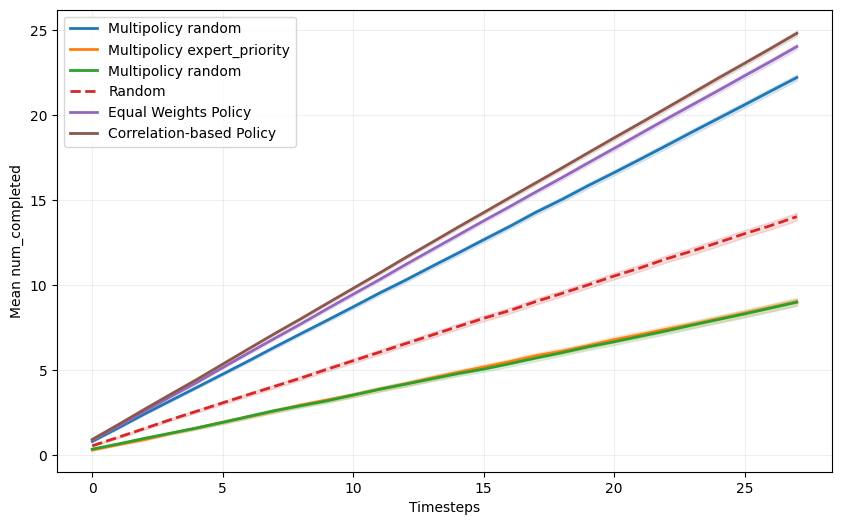

In [138]:
sim_utils.plot_simulation(choice_policies + baseline_policies, 'num_completed')

#### Inspect number of users per state

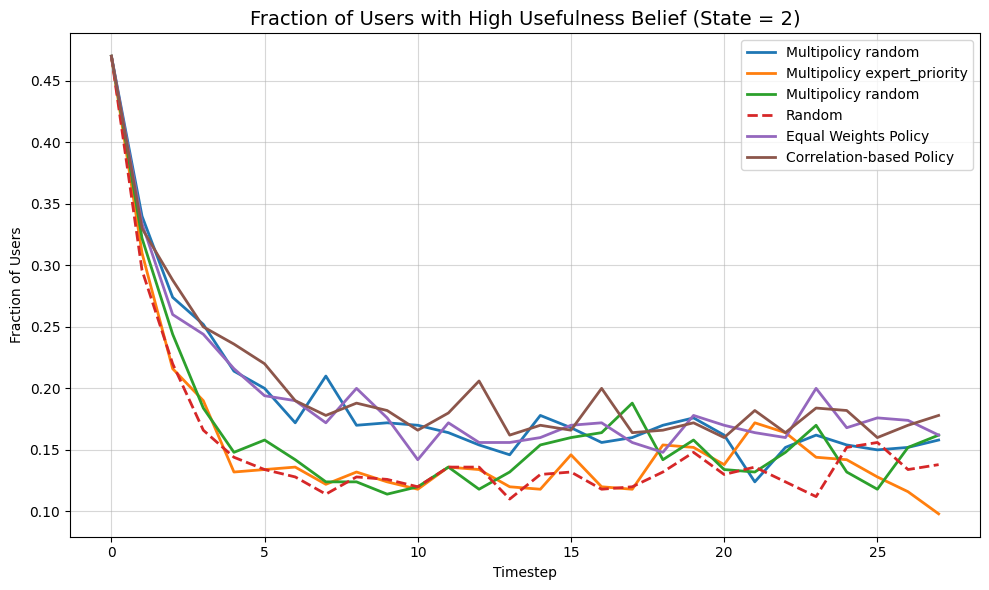

In [139]:
target_feature = 'Usefulness Belief'

HIGH_MOTIVATION_THRESHOLD = 2
feature_idx = feature_names.index(target_feature)
timesteps = np.arange(NUM_TIMESTEPS)

plt.figure(figsize=(10, 6))

for sim_res in all_policies:
    policy_label = sim_res['policy'].iloc[0]
    states = np.stack(sim_res['state']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
    
    # Extract motivation and count users meeting the threshold at each step
    motivation_data = states[:, :, feature_idx]
    high_motivation_trend = np.sum(motivation_data >= HIGH_MOTIVATION_THRESHOLD, axis=0) / NUM_USERS
    
    plt.plot(timesteps, high_motivation_trend, label=policy_label, linewidth=2, linestyle='--' if 'Random' in policy_label else '-')

plt.title(f'Fraction of Users with High {target_feature} (State = {HIGH_MOTIVATION_THRESHOLD})', fontsize=14)
plt.xlabel('Timestep')
plt.ylabel('Fraction of Users')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

#### Inspect diversity

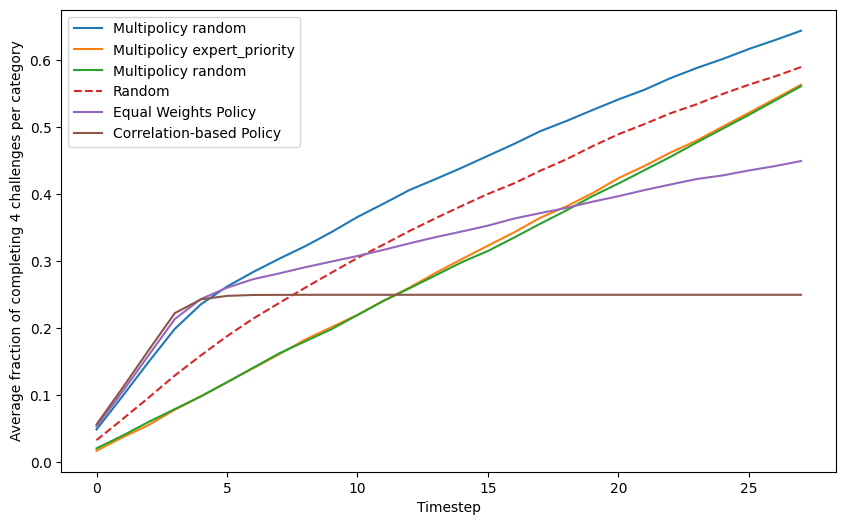

In [140]:
plt.figure(figsize=(10, 6))
for idx, sim_res in enumerate(all_policies):
    counts_per_category = np.stack(sim_res['counts_per_category']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
    max_count_per_category = 4
    counts_per_category = np.clip(counts_per_category, 0, max_count_per_category)
    counts = counts_per_category.sum(axis=2)
    fraction_completed = counts / (max_count_per_category*4)
    mean_fraction_completed = fraction_completed.mean(axis=0)
    style = '--' if 'Random' in sim_res['policy'].iloc[0] else '-'
    plt.plot(mean_fraction_completed, label=sim_res['policy'].iloc[0], linestyle=style)
plt.xlabel('Timestep')
plt.ylabel(f'Average fraction of completing {max_count_per_category} challenges per category')
plt.legend()

#### Analyze dropout / retention

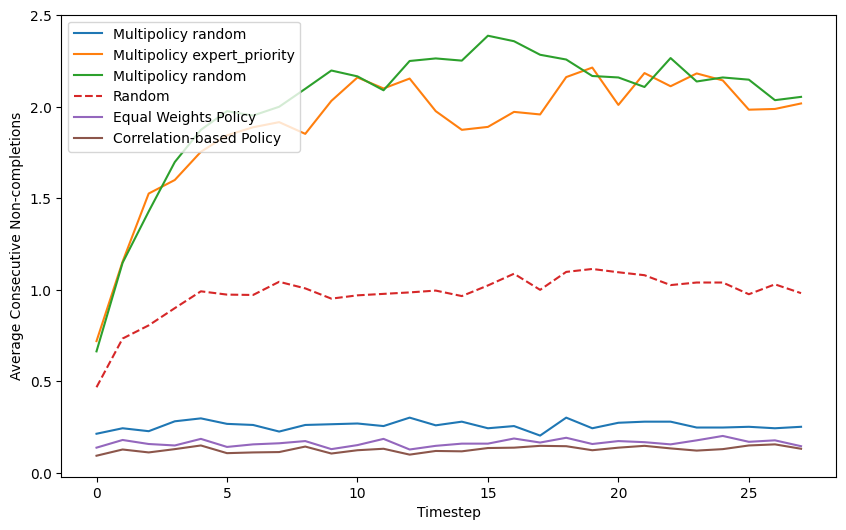

,Policy,Avg Max Streak,Median Max Streak,% Users with 5+ Day Non-completions,Final Avg Streak
5,Correlation-based Policy,1.286,1.0,0.0,0.132
4,Equal Weights Policy,1.430,1.0,0.0,0.146
0,Multipolicy random,1.860,2.0,0.6,0.252
3,Random,4.230,4.0,37.6,0.982
1,Multipolicy expert_priority,6.622,6.0,82.0,2.018
2,Multipolicy random,6.970,6.0,83.2,2.054


In [141]:
def get_consecutive_failures(df):
    # Group by user and find sequences of the same 'completed' value
    # 'block' increments every time 'completed' changes
    df = df.sort_values(['user', 't'])
    df['block'] = (df['completed'] != df.groupby('user')['completed'].shift()).cumsum()
    
    # Calculate the cumulative count within each block
    df['consecutive_no'] = df.groupby(['user', 'block']).cumcount() + 1
    
    # We only care about streaks where completed == 0
    df.loc[df['completed'] == 1, 'consecutive_no'] = 0
    return df

dropout_threshold = 5
summary_stats = []

plt.figure(figsize=(10, 6))
for sim_res in choice_policies + baseline_policies:
    sim_res = get_consecutive_failures(sim_res)
    mean_consecutive_no = sim_res.groupby('t')['consecutive_no'].mean()
    user_max_streaks = sim_res.groupby('user')['consecutive_no'].max()
    
    summary_stats.append({
        'Policy': sim_res['policy'].iloc[0],
        'Avg Max Streak': user_max_streaks.mean(),
        'Median Max Streak': user_max_streaks.median(),
        '% Users with 5+ Day Non-completions': (user_max_streaks >= 5).mean() * 100,
        'Final Avg Streak': sim_res[sim_res['t'] == sim_res['t'].max()]['consecutive_no'].mean()
    })

    plt.plot(mean_consecutive_no, label=sim_res['policy'].iloc[0], linestyle='--' if 'Random' in sim_res['policy'].iloc[0] else '-')
plt.xlabel('Timestep')
plt.ylabel('Average Consecutive Non-completions')
plt.legend()
plt.show()

df_comparison = pd.DataFrame(summary_stats)
df_comparison.sort_values('Avg Max Streak')


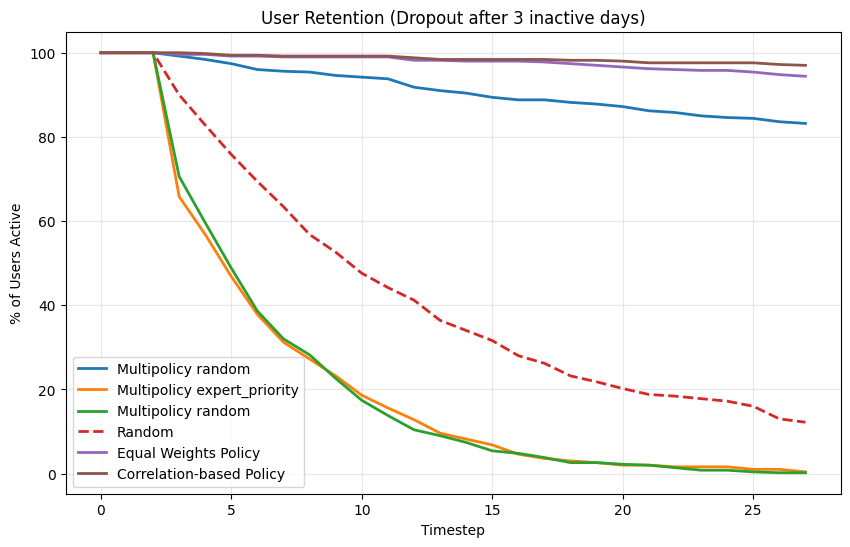

In [142]:
def apply_post_hoc_dropout(df, threshold=3):
    if 'consecutive_no' not in df.columns:
        df = get_consecutive_failures(df)
    
    dropouts = df[df['consecutive_no'] >= threshold]
    
    # Get the earliest timestep for each user where they dropped out
    first_dropout_t = dropouts.groupby(['policy', 'user'])['t'].min().reset_index()
    first_dropout_t.rename(columns={'t': 'dropout_time'}, inplace=True)
    
    df = df.merge(first_dropout_t, on=['policy', 'user'], how='left')
    
    # Keep rows where 't' <= 'dropout_time' 
    # (or keep all rows if dropout_time is NaN, meaning they never dropped out)
    df_active = df[(df['t'] <= df['dropout_time']) | (df['dropout_time'].isna())].copy()
    
    return df_active.drop(columns=['dropout_time'])

plt.figure(figsize=(10, 6))

for sim_res in choice_policies + baseline_policies:
    # Apply dropout
    df_active = apply_post_hoc_dropout(sim_res, threshold=3)
    
    # Count unique users at each t
    survival = df_active.groupby('t')['user'].nunique()
    # Normalize by starting count
    survival_rate = (survival / sim_res['user'].nunique()) * 100
    
    plt.plot(survival_rate, label=sim_res['policy'].iloc[0], linewidth=2, linestyle='--' if 'Random' in sim_res['policy'].iloc[0] else '-')

plt.ylabel("% of Users Active")
plt.xlabel("Timestep")
plt.title("User Retention (Dropout after 3 inactive days)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()